# CIFAR-10

In [1]:
import os
os.environ["PYTHONWARNINGS"] = "ignore"

import warnings
warnings.filterwarnings('ignore')

import sys

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), os.pardir)))

import random

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, Subset, ConcatDataset

from torchvision import models
import torchvision.datasets as datasets
import torchvision.transforms as transforms

from sklearn.neighbors import KernelDensity

from tqdm import tqdm

import numpy as np
import cupy as cp
import matplotlib.pyplot as plt
from PIL import Image

from joblib import Parallel, delayed

from utils import renormalize_image, vectorize_tensor, reconstruct_tensor
import ld

device = torch.device("cuda:2" if torch.cuda.is_available() else "cpu")

## Setup

### General

In [2]:
def set_random_seed(seed):
    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)

    cp.random.seed(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

load = True

set_random_seed(62)
k = 5
bandwidth = 0.05
bandwidth_AE = 0.05
eps = np.asarray(1.0e-5)
plot_num = 20
paper_plot_num = 1

### Dataset

In [3]:
class NumpyDataset(Dataset):
    def __init__(self, data, labels, transform=None):
        """
        Args:
            data (numpy.array): Array of shape (N, H, W, C).
            labels (numpy.array): Labels array of shape (N,).
            transform (callable, optional): Transformations to apply to each sample.
        """
        self.data = data
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img = self.data[idx]
        label = self.labels[idx]

        # Convert (H, W, C) -> (C, H, W) for PyTorch
        img = torch.tensor(img).permute(2, 0, 1).float() / 255.0

        # Apply transformation if provided
        if self.transform:
            img = self.transform(img)

        return img, label

In [4]:
D = 32*32*3
S = (2, 2, 2, 2, 2, 3, 2, 2, 2, 2, 2)
train_size_per_class = 5000
new_sample_size_per_class = 1000
num_class = 10

# Print dataset statistics
print(f"Train size: {train_size_per_class * num_class}")
print(f"New sample size: {new_sample_size_per_class * num_class}")
print(f"Number of classes: {num_class}")
print(f"Number of features: {D}")

Train size: 50000
New sample size: 10000
Number of classes: 10
Number of features: 3072


In [5]:
train_dataset = datasets.CIFAR10(root='./data', download=True, train=True, transform=transforms.Compose([transforms.ToTensor()]))
test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transforms.Compose([transforms.ToTensor(),transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),]))

save_dir = './data/CIFAR10_images'
if not os.path.exists(save_dir):
    os.makedirs(save_dir)
    # Save images by class
    for class_label in range(num_class):
        class_dir = os.path.join(save_dir, str(class_label))
        if not os.path.exists(class_dir):
            os.makedirs(class_dir)

        basis = np.where(np.array(train_dataset.targets) == class_label)[0]
        for i, idx in enumerate(basis):
            img, _ = train_dataset[idx]
            img = transforms.ToPILImage()(img)
            img.save(os.path.join(class_dir, f'{i}.png'))

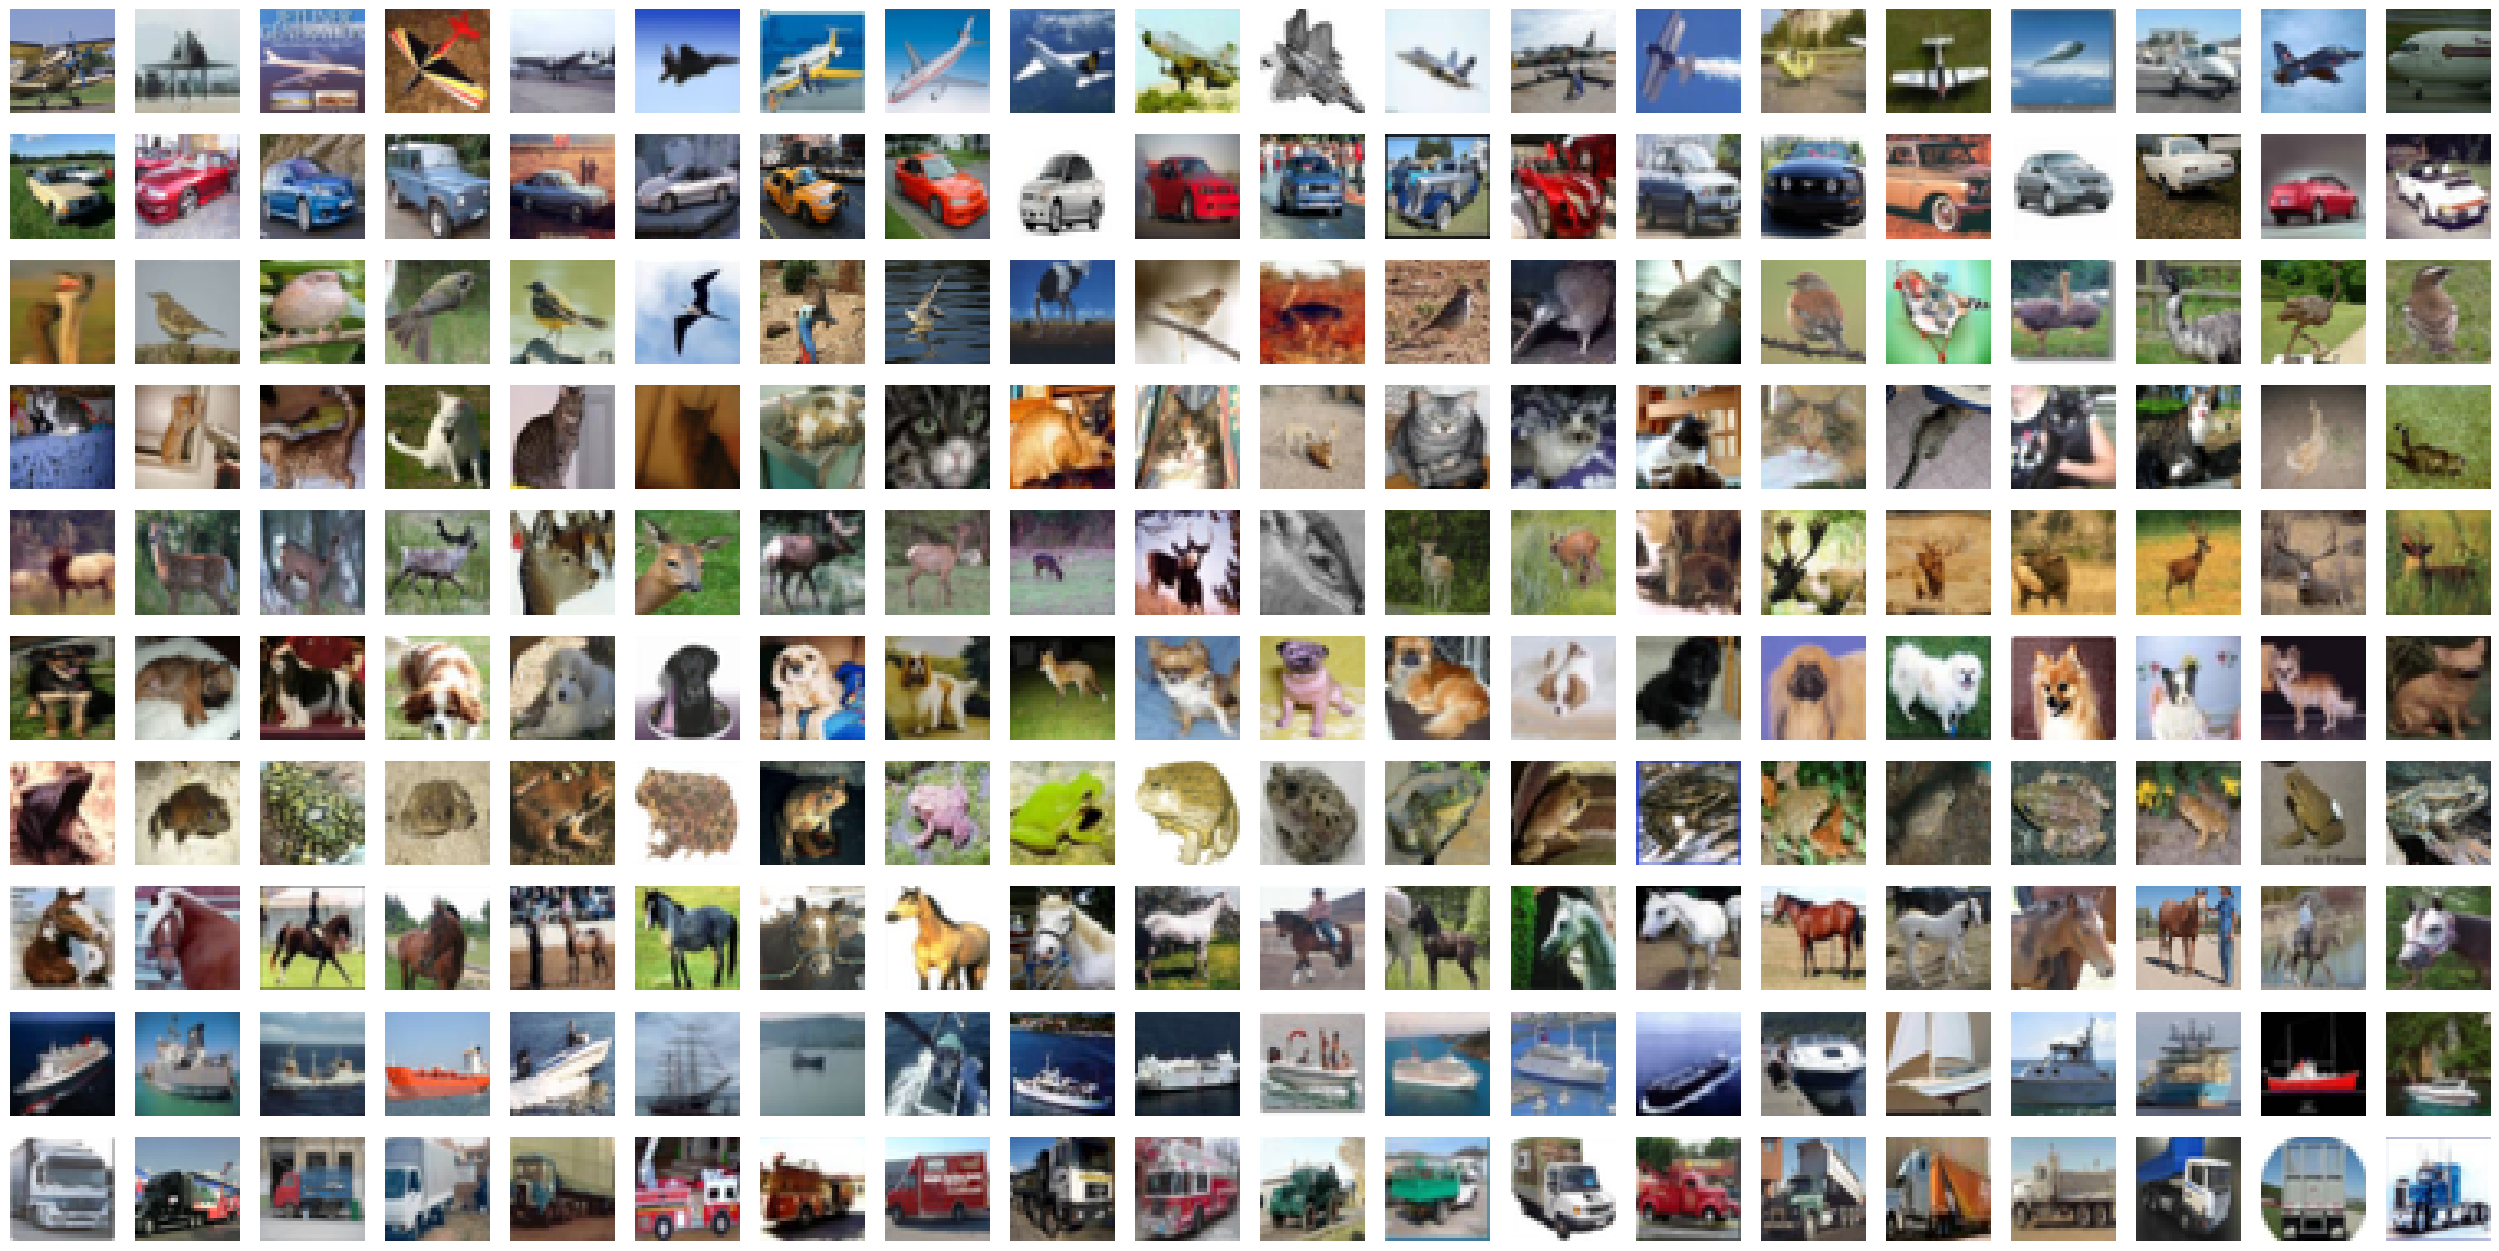

In [6]:
# Function to load images from a directory
def load_images_from_folder(folder, max_images=20):
    images = []
    for filename in os.listdir(folder)[:max_images]:
        file_path = os.path.join(folder, filename)
        with Image.open(file_path) as img:  # Ensure the file handle is closed after opening
            images.append(img.copy())  # Make a copy of the image to keep it in memory
    return images

P_class = []

for class_ in range(num_class):
    class_folder = os.path.join(save_dir, str(class_))
    images = load_images_from_folder(class_folder, max_images=train_size_per_class)

    P = []
    for img in images:
        img = img.resize((32, 32))
        array_obj = np.asarray(img).reshape(S)
        P.append(array_obj)

    P_class.append(np.array(P))

# Load and display images horizontally for each class
plt.figure(figsize=(32, 16))
for class_ in range(num_class):
    for i in range(plot_num):
        plt.subplot(num_class, plot_num, class_ * plot_num + i + 1)
        plt.imshow(P_class[class_][i].reshape((32, 32, 3)), cmap='gray', vmin=0, vmax=255)
        plt.axis('off')  # Hide axes

plt.show()

## Pseudo-Non-Linear Data Augmentation

### Legendre Decomposition (Many-Body Approximation)

In [7]:
B_LD = ld.default_B(S, 5, cp.get_array_module(P[0]))
print(f"Dimension of Base Sub-Manifold: {B_LD.shape[0]}")

# Store all intermediate results to disk
if load:
    # Load all intermediate results from disk
    results = np.load('results_LD.npz')
    scaleX_class = results['scaleX_class']
    Q_class = results['Q_class']
    theta_class = results['theta_class']
    X_recons_class = results['X_recons_class']
else:
    import tempfile
    temp_dir = tempfile.mkdtemp(dir='/data/pbb/tmp')

    def LD_helper(i, class_):
        _, _, scaleX, Q, theta = ld.LD(P_class[class_][i], B=B_LD, verbose=False, n_iter=1000, lr=1e-1)
        return (scaleX, Q, theta)


    results = Parallel(n_jobs=30, temp_folder=temp_dir)(delayed(LD_helper)(i, class_) for i in range(train_size_per_class) for class_ in range(num_class))

    scaleX_class = []
    Q_class = []
    theta_class = []
    X_recons_class = []

    for class_ in range(num_class):
        scaleX_list = []
        Q_list = []
        theta_list = []
        X_recons_list = []
        for i in range(train_size_per_class):
            result = results[i*num_class + class_]

            scaleX_list.append(result[0])
            Q_list.append(result[1])
            theta_list.append(result[2])
            X_recons = (result[1] * result[0]).astype(np.int32)
            X_recons_list.append(X_recons)

        scaleX_class.append(np.array(scaleX_list))
        Q_class.append(np.array(Q_list))
        theta_class.append(np.array(theta_list))
        X_recons_class.append(np.array(X_recons_list))

    np.savez('results_LD.npz', scaleX_class=scaleX_class, Q_class=Q_class, theta_class=theta_class, X_recons_class=X_recons_class)

Dimension of Base Sub-Manifold: 1410


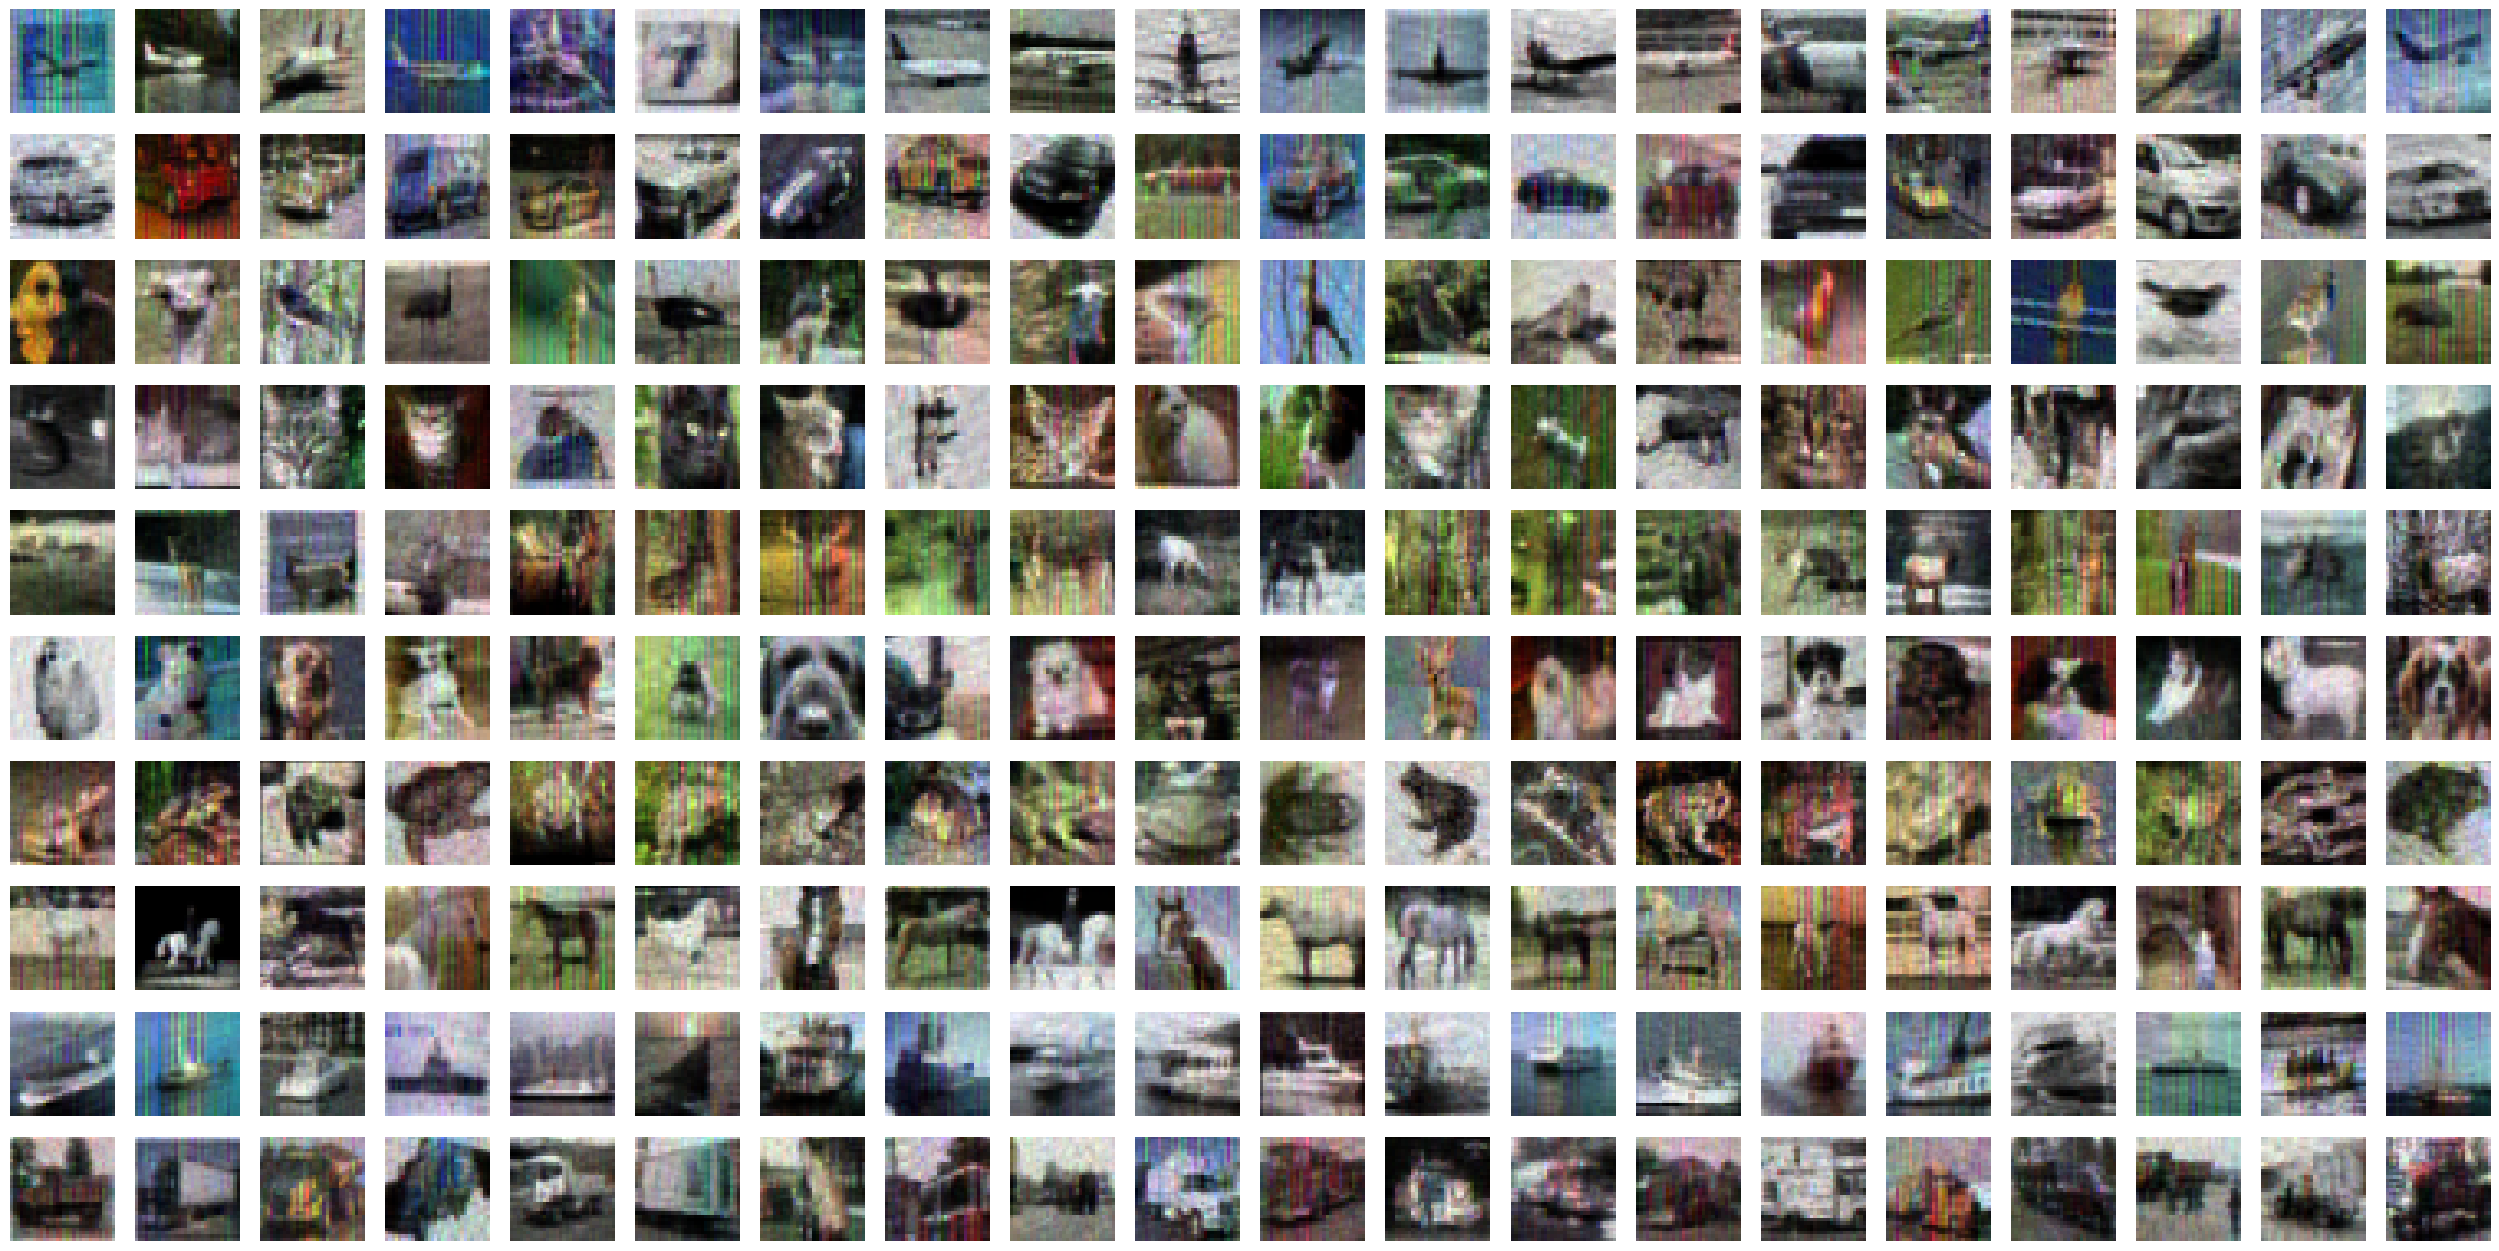

In [8]:
# Load and display images horizontally for each class
plt.figure(figsize=(32, 16))
for class_ in range(num_class):
    for i in range(plot_num):
        plt.subplot(num_class, plot_num, class_ * plot_num + i + 1)
        plt.imshow(renormalize_image(X_recons_class[class_][i]).reshape((32, 32, 3)), cmap='gray', vmin=0, vmax=255)
        plt.axis('off')  # Hide axes

plt.show()

# plt.figure(figsize=(32, 16))
# for class_ in range(num_class):
#     for i in range(plot_num):
#         plt.subplot(num_class, plot_num, class_ * plot_num + i + 1)
#         plt.imshow(theta_class[class_][i].reshape((32, 32, 3)), cmap='coolwarm', vmin=-15, vmax=15)
#         plt.axis('off')  # Hide axes

# plt.show()

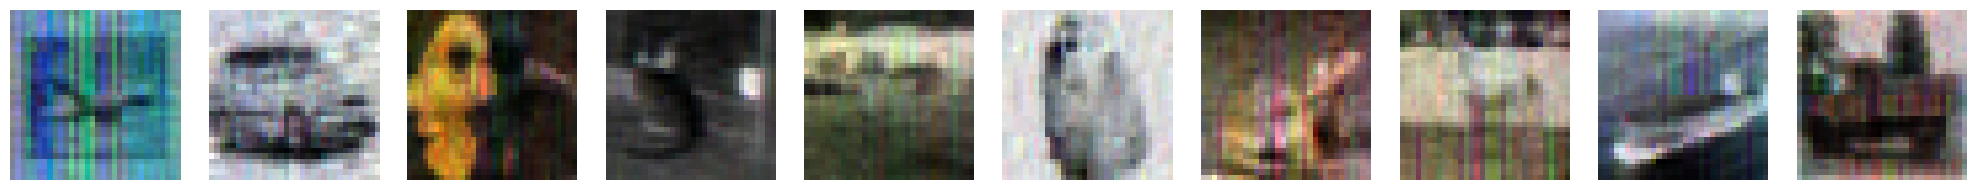

In [9]:
plt.figure(figsize=(20, 2))
for class_ in range(num_class):
    for i in range(paper_plot_num):
        plt.subplot(paper_plot_num, num_class, class_ * paper_plot_num + i + 1)
        plt.imshow(renormalize_image(X_recons_class[class_][i]).reshape((32, 32, 3)), cmap='gray', vmin=0, vmax=255)
        plt.axis('off')  # Hide axes

plt.tight_layout()

plt.savefig('../Figures/CIFAR/default/LD.pdf', format='pdf')

plt.show()

# # Find the nearest distance between every new sample among the training set in terms of norm.
# plt.figure(figsize=(20, 2))
# for class_ in range(num_class):
#     for i in range(paper_plot_num):
#         plt.subplot(paper_plot_num, num_class, class_ * paper_plot_num + i + 1)
#         plt.imshow(theta_class[class_][i].reshape((32, 32, 3)), cmap='coolwarm', vmin=-15, vmax=15)
#         plt.axis('off')  # Hide axes

# plt.tight_layout()

# plt.savefig('../Figures/CIFAR/default/LD_parameter.pdf', format='pdf')

# plt.show()

#### Fitting on Projected Points

In [10]:
sampled_theta_class = []

for class_ in range(num_class):
    reduced_theta = vectorize_tensor(theta_class[class_], B_LD)

    # Fit a KDE to the theta values
    kde = KernelDensity(kernel='gaussian', bandwidth=bandwidth).fit(reduced_theta)
    # Sample new data from the KDE
    sampled_reduced_theta = kde.sample(n_samples=new_sample_size_per_class)

    sampled_theta = reconstruct_tensor(sampled_reduced_theta, (new_sample_size_per_class, *S), B_LD)
    sampled_theta_class.append(sampled_theta)

#### Construct Local Data Sub-Manifold

In [11]:
# Construct the constrained coordinates
# B_BP = ld.block_B([14, 14], [15, 15])
B_BP = ld.default_B(S, 4, cp.get_array_module(P[0]))
print(f"Dimension of Local Data Sub-Manifold: {D - B_BP.shape[0]}")

# Compute every datapoint's eta_hat (served as the linear constraints)
eta_hat_class = []

for class_ in range(num_class):
    eta_hat_list = []
    for i in range(P_class[class_].shape[0]):
        xp = cp.get_array_module(P_class[class_][i])
        P = (P_class[class_][i] + eps) / scaleX_class[class_][i]
        eta_hat = ld.get_eta(P, len(S), xp)
        eta_hat_list.append(eta_hat)

    eta_hat_class.append(cp.asarray(eta_hat_list))

Dimension of Local Data Sub-Manifold: 2334


#### Backward Projection

In [12]:
if load:
    # Load all intermediate results from disk
    results_BP = np.load('results_BP.npz')
    sampled_P_BP_class = results_BP['sampled_P_BP_class']
    sampled_theta_BP_class = results_BP['sampled_theta_BP_class']
    sampled_X_BP_class = results_BP['sampled_X_BP_class']
else:
    # Use a custom temporary directory
    import tempfile
    temp_dir = tempfile.mkdtemp(dir='/data/pbb/tmp')


    def BP_helper(i, class_):
        N = ld.kNN(sampled_theta_class[class_][i], theta_class[class_], k=k)
        avg_scale = np.mean(scaleX_class[class_][N])
        avg_eta_hat = np.mean(eta_hat_class[class_][N], axis=0)
        _, _, P, theta = ld.BP(sampled_theta_class[class_][i], [(P_class[class_][j] + eps) / scaleX_class[class_][j] for j in N], avg_eta_hat, avg_scale, B=B_BP, verbose=False, n_iter=1000, lr=1e-1)
        X_recons_ = (P).astype(np.int32).reshape(-1)
        return (P, theta, X_recons_)

    results = Parallel(n_jobs=30, temp_folder=temp_dir)(delayed(BP_helper)(i, class_) for i in range(new_sample_size_per_class) for class_ in range(num_class))

    sampled_P_BP_class = []
    sampled_theta_BP_class = []
    sampled_X_BP_class = []

    for class_ in range(num_class):
        sampled_P_BP = []
        sampled_theta_BP = []
        sampled_X_BP = []
        for i in range(new_sample_size_per_class):
            result = results[i*num_class + class_]

            sampled_P_BP.append(result[0])
            sampled_theta_BP.append(result[1])
            sampled_X_BP.append(result[2])

        sampled_P_BP_class.append(np.array(sampled_P_BP))
        sampled_theta_BP_class.append(np.array(sampled_theta_BP))
        sampled_X_BP_class.append(np.array(sampled_X_BP))

    np.savez('results_BP.npz', sampled_P_BP_class=sampled_P_BP_class, sampled_theta_BP_class=sampled_theta_BP_class, sampled_X_BP_class=sampled_X_BP_class)

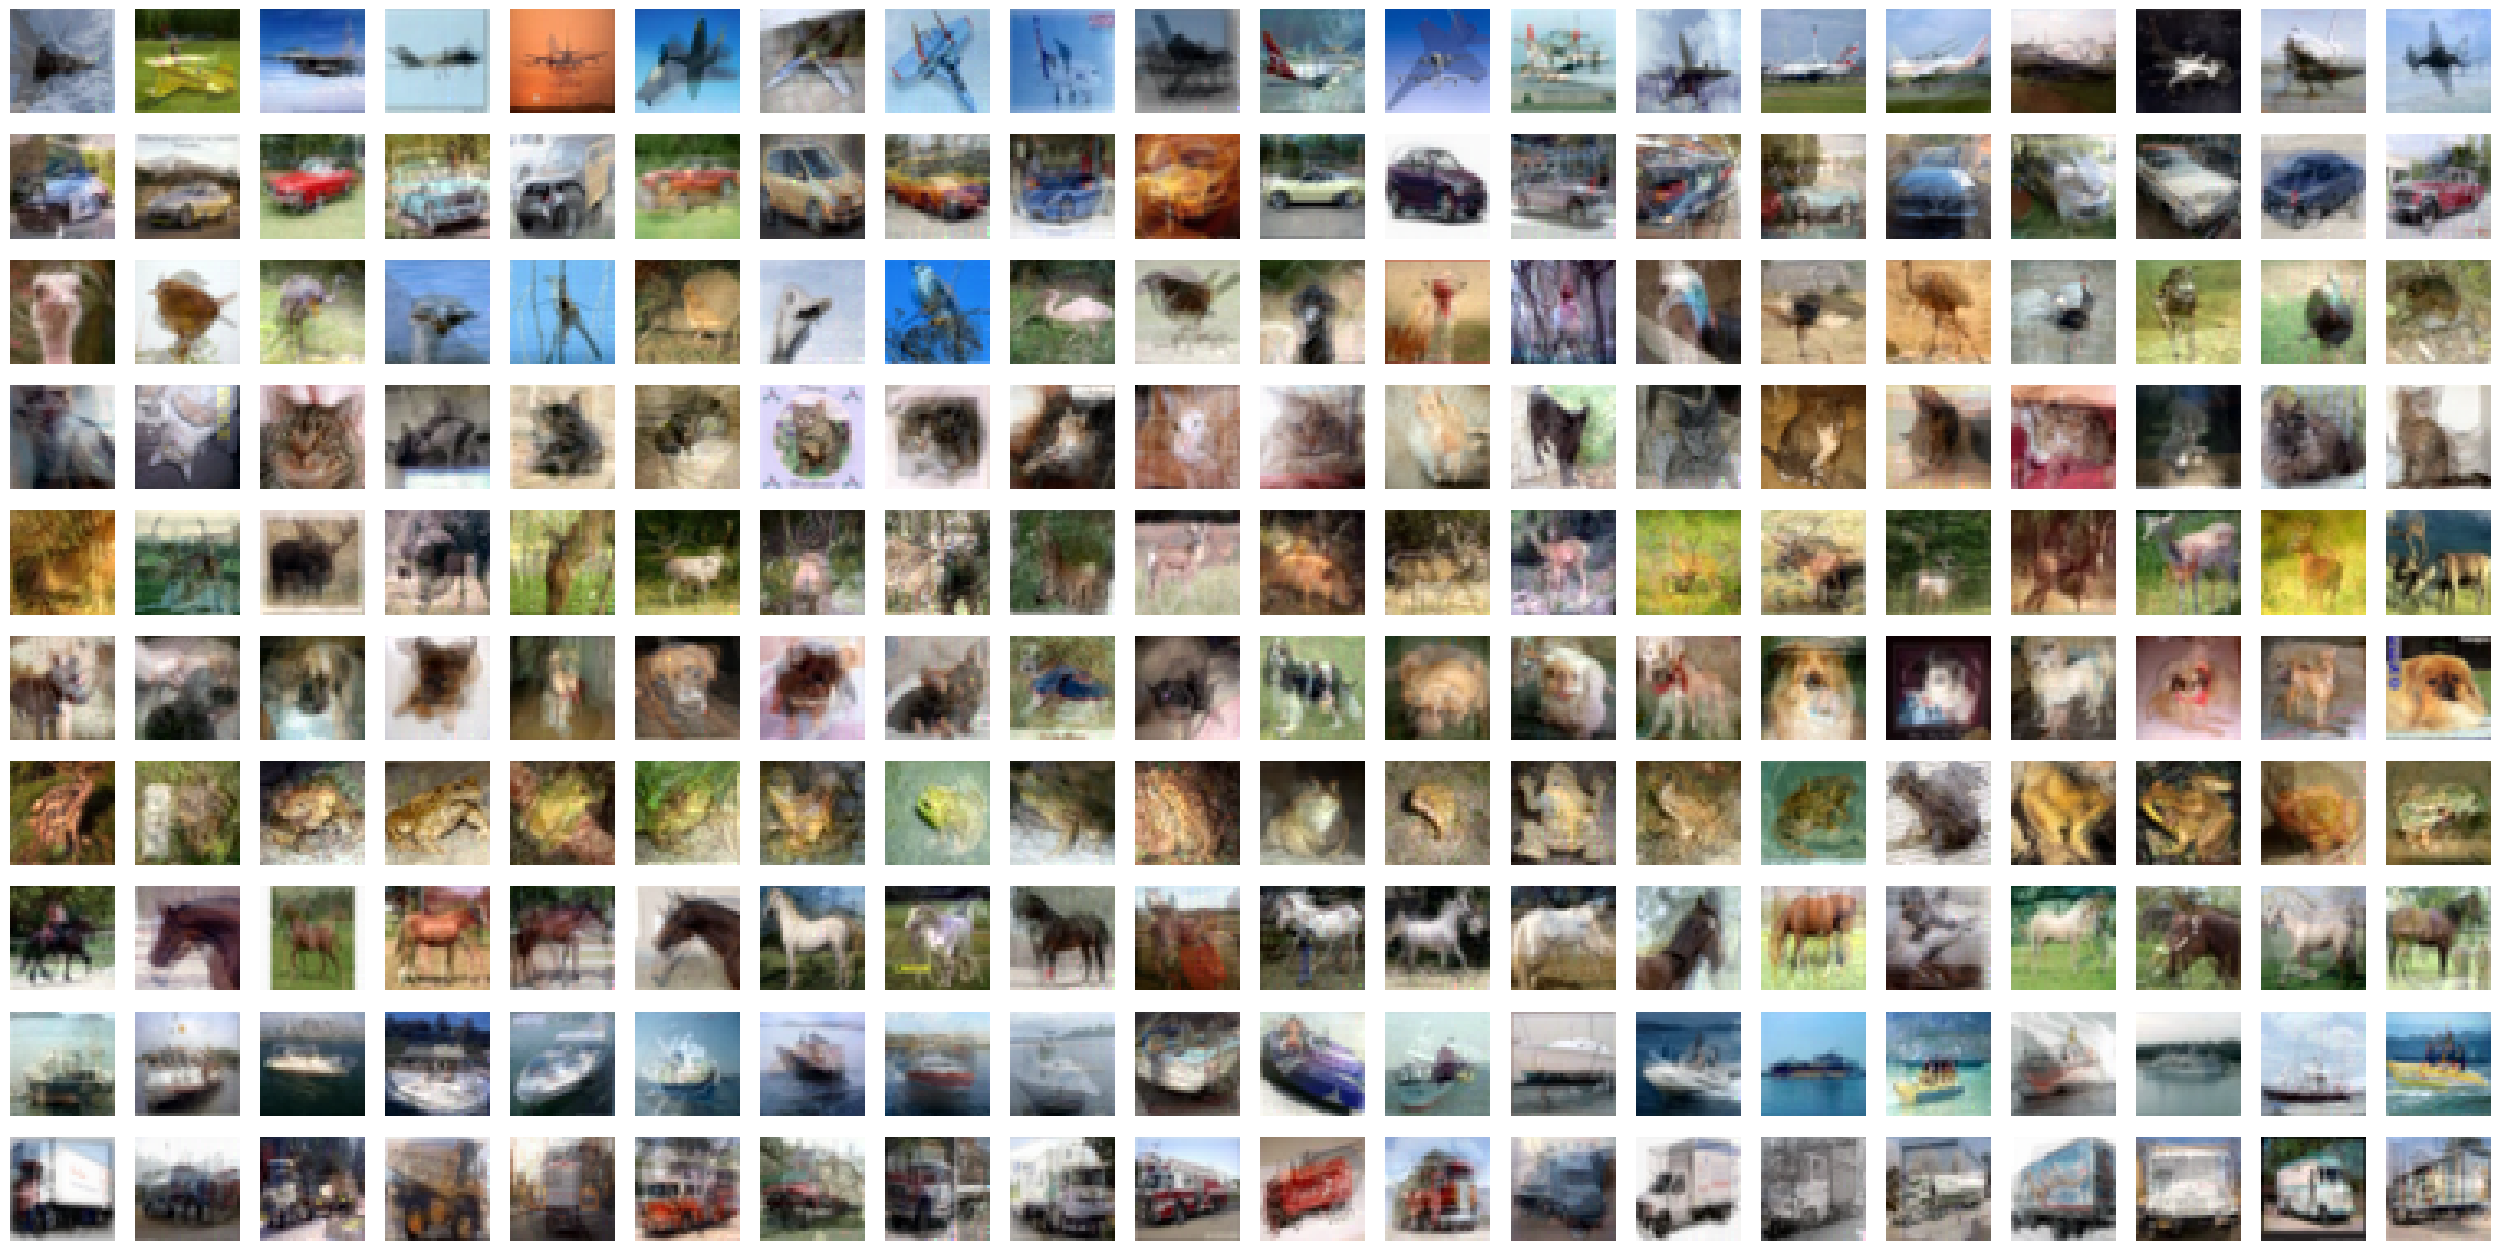

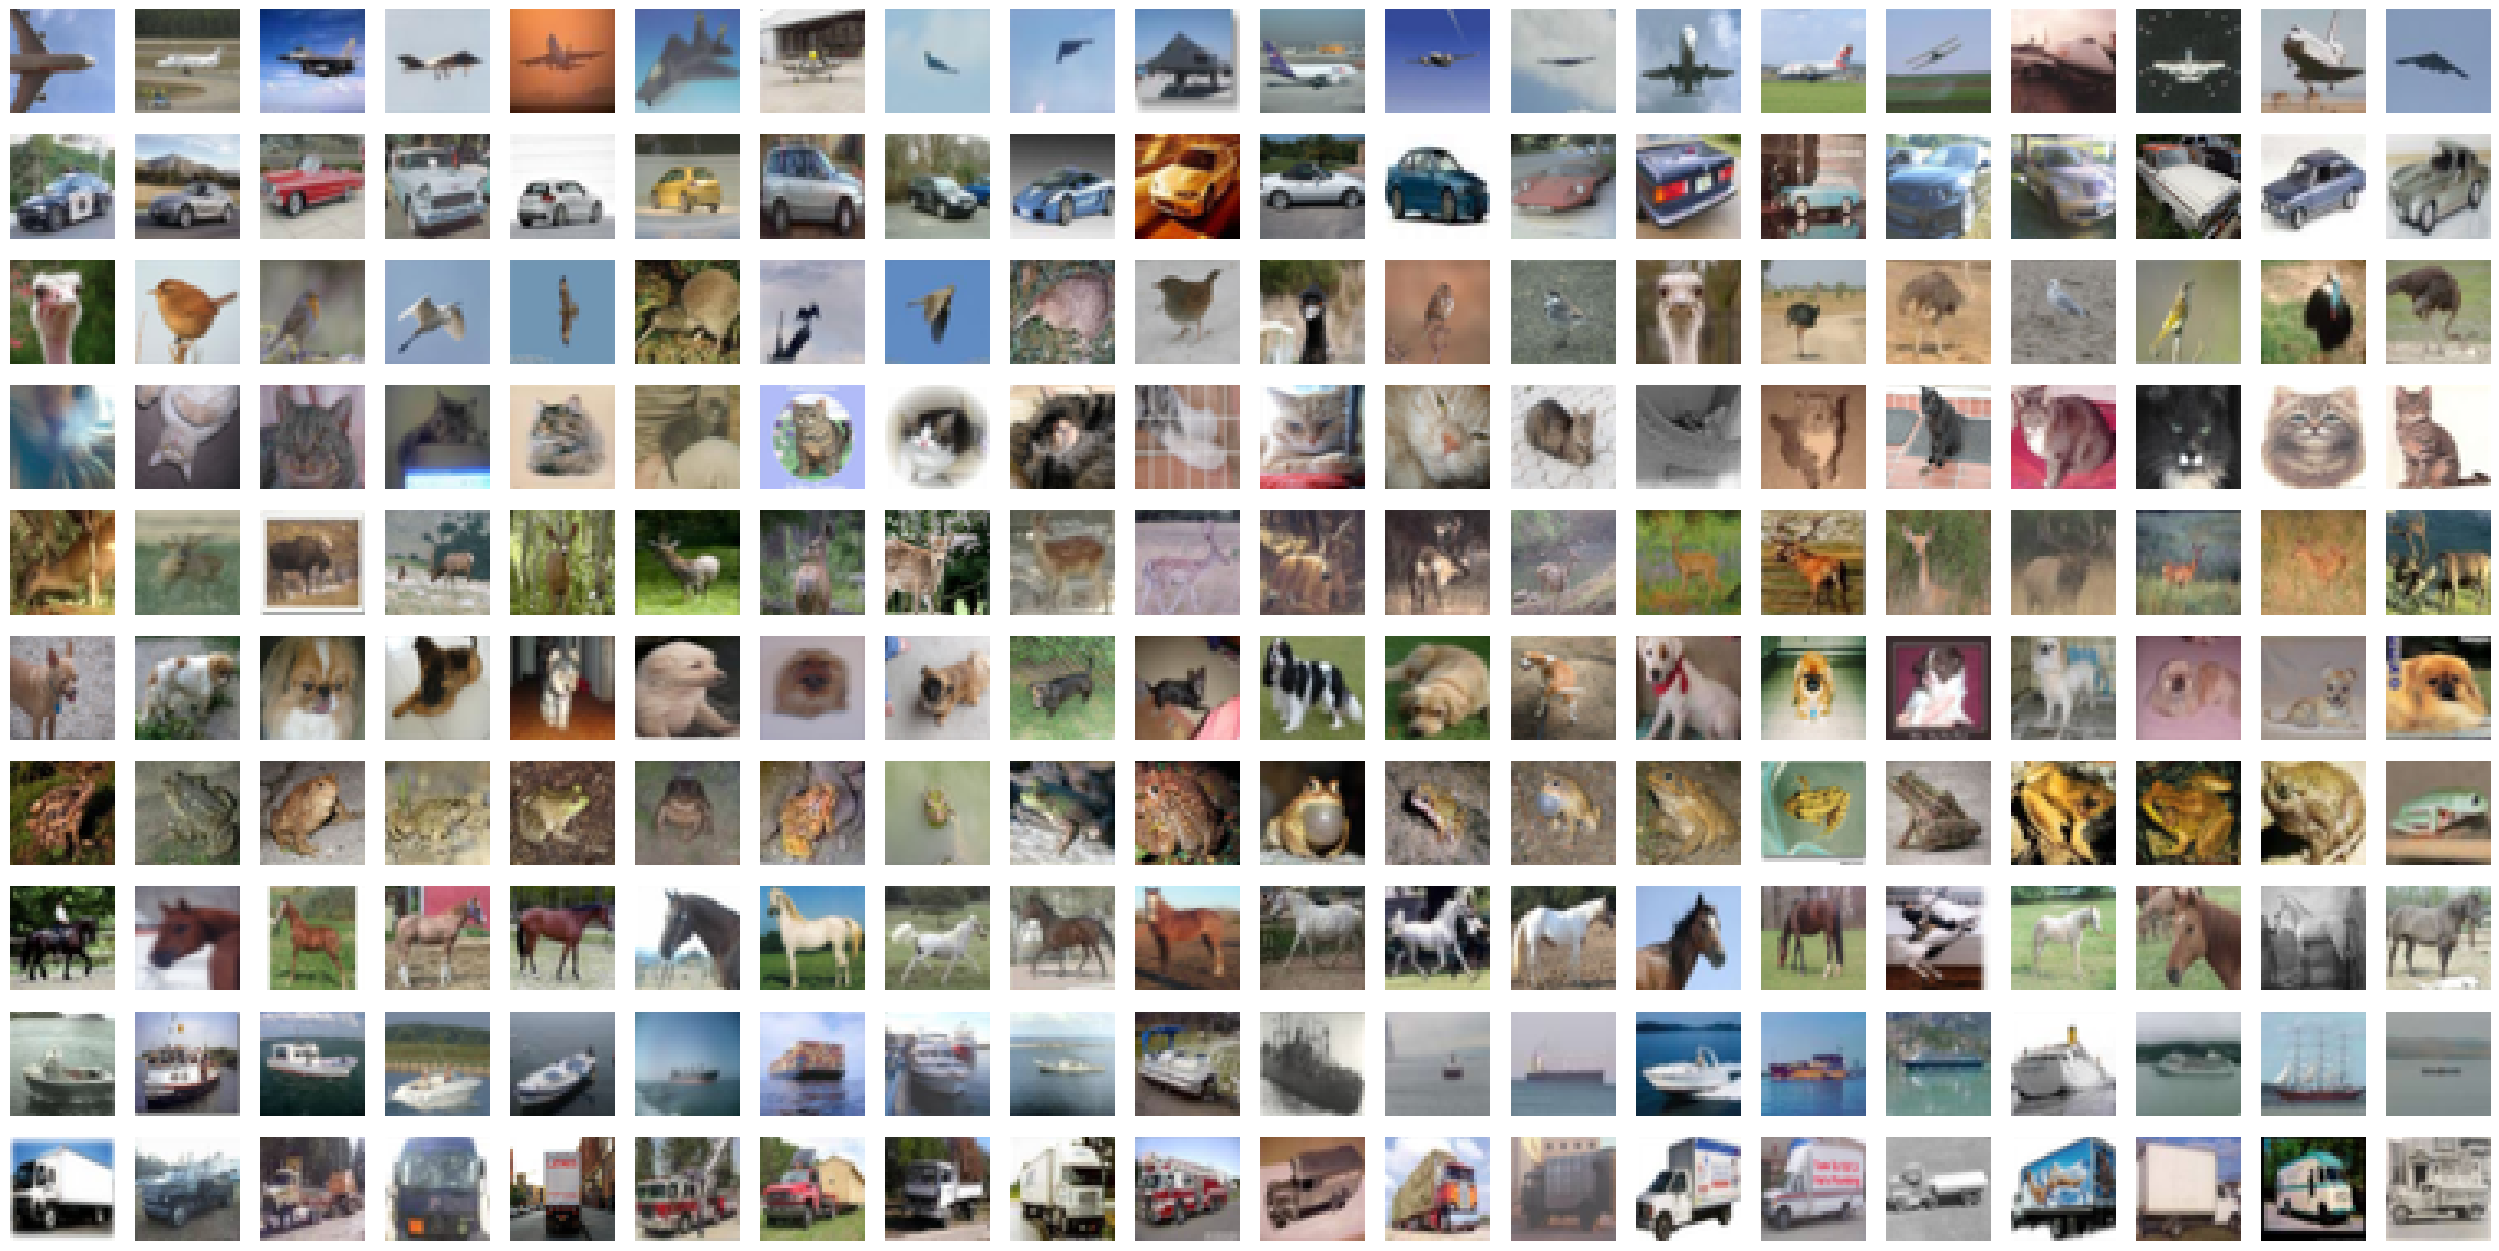

In [13]:
plt.figure(figsize=(32, 16))
for class_ in range(num_class):
    for i in range(plot_num):
        plt.subplot(num_class, plot_num, class_ * plot_num + i + 1)
        plt.imshow(renormalize_image(sampled_X_BP_class[class_][i]).reshape((32, 32, 3)), cmap='gray', vmin=0, vmax=255)
        plt.axis('off')  # Hide axes

plt.show()

# Find the nearest distance between every new sample among the training set in terms of norm.
plt.figure(figsize=(32, 16))
for class_ in range(num_class):
    for i in range(plot_num):
        norm = [np.linalg.norm(sampled_X_BP_class[class_][i].reshape((32, 32, 3)) - p.reshape((32, 32, 3))) for p in P_class[class_]]
        idx = np.argmin(norm)
        plt.subplot(num_class, plot_num, class_ * plot_num + i + 1)
        plt.imshow(P_class[class_][idx].reshape((32, 32, 3)), cmap='gray', vmin=0, vmax=255) # [0, 255]
        plt.axis('off')  # Hide axes

plt.show()

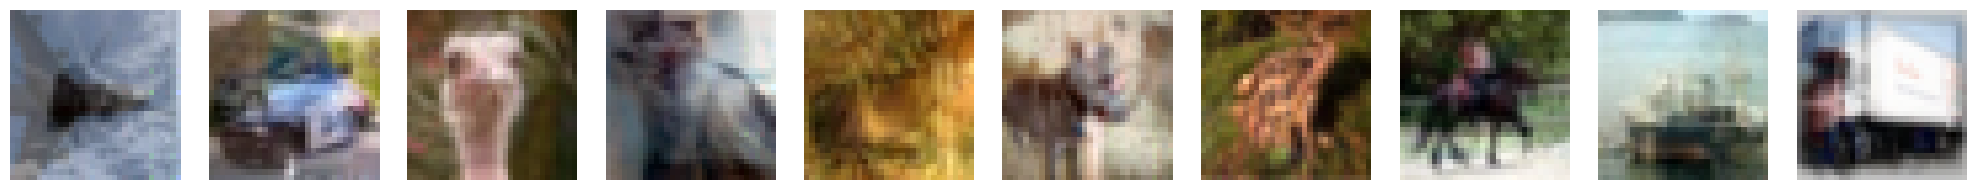

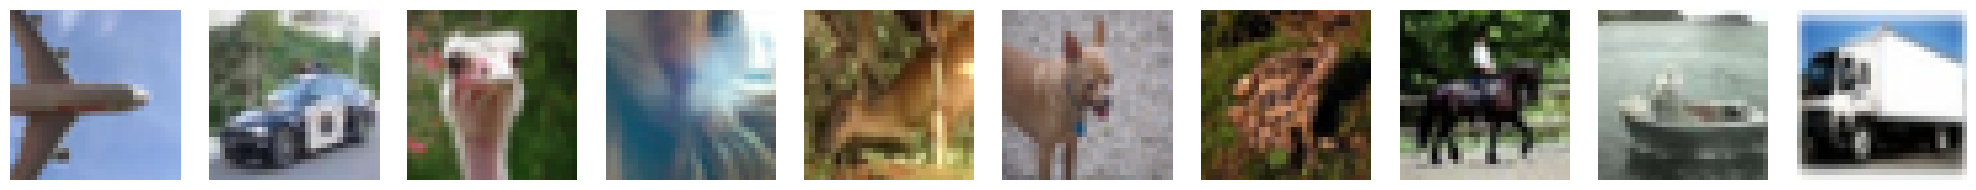

In [14]:
plt.figure(figsize=(20, 2))
for class_ in range(num_class):
    for i in range(paper_plot_num):
        plt.subplot(paper_plot_num, num_class, class_ * paper_plot_num + i + 1)
        plt.imshow(renormalize_image(sampled_X_BP_class[class_][i]).reshape((32, 32, 3)), cmap='gray', vmin=0, vmax=255)
        plt.axis('off')  # Hide axes

plt.tight_layout()

plt.savefig('../Figures/CIFAR/default/BP.pdf', format='pdf')

plt.show()

# Find the nearest distance between every new sample among the training set in terms of norm.
plt.figure(figsize=(20, 2))
for class_ in range(num_class):
    for i in range(paper_plot_num):
        norm = [np.linalg.norm(sampled_X_BP_class[class_][i].reshape((32, 32, 3)) - p.reshape((32, 32, 3))) for p in P_class[class_]]
        idx = np.argmin(norm)
        plt.subplot(paper_plot_num, num_class, class_ * paper_plot_num + i + 1)
        plt.imshow(P_class[class_][idx].reshape((32, 32, 3)), cmap='gray', vmin=0, vmax=255) # [0, 255]
        plt.axis('off')  # Hide axes

plt.tight_layout()

plt.savefig('../Figures/CIFAR/default/BP_compare.pdf', format='pdf')

plt.show()

## Data Augmentation with Autoencoder

Some remark on the Autoencoder architecture and training for CIFAR-10 specifically:
1. The training set should **not** be normalize in order to obtain a good result.
2. Since we're now dealing with colored images, more careful permutation is required.

Due the the above, the data processing pipeline is slightly different from MNIST.

In [15]:
class Encoder(nn.Module):
    def __init__(self, input_channels=3, feature_maps=[12, 24, 48]):
        super(Encoder, self).__init__()
        self.layers = nn.Sequential(
            nn.Conv2d(input_channels, feature_maps[0], kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(feature_maps[0], feature_maps[1], kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(feature_maps[1], feature_maps[2], kernel_size=4, stride=2, padding=1),
            nn.ReLU()
        )

    def forward(self, x):
        return self.layers(x)


class Decoder(nn.Module):
    def __init__(self, output_channels=3, feature_maps=[48, 24, 12]):
        super(Decoder, self).__init__()
        self.layers = nn.Sequential(
            nn.ConvTranspose2d(feature_maps[0], feature_maps[1], kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(feature_maps[1], feature_maps[2], kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(feature_maps[2], output_channels, kernel_size=4, stride=2, padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.layers(x)

100%|██████████| 100/100 [12:15<00:00,  7.35s/it]


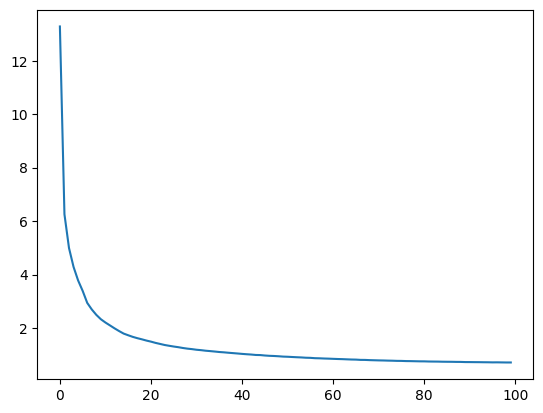

In [16]:
train_loader_original = DataLoader(dataset=datasets.CIFAR10(root='./data', download=True, train=True, transform=transforms.Compose([transforms.ToTensor(), ])), batch_size=64, shuffle=True)

enc = Encoder(input_channels=3, feature_maps=[12, 24, 48]).to(device)
dec = Decoder(output_channels=3, feature_maps=[48, 24, 12]).to(device)
loss_fn = nn.MSELoss()
optimizer_enc = torch.optim.Adam(enc.parameters(), lr=1e-3)
optimizer_dec = torch.optim.Adam(dec.parameters(), lr=1e-3)

train_loss = []
num_epochs = 100

for epoch in tqdm(range(num_epochs)):
    train_epoch_loss = 0
    for imgs, _ in train_loader_original:
        imgs = imgs.to(device)

        # Forward pass
        latents = enc(imgs)  # Encode to latent space
        output = dec(latents)  # Reconstruct image

        # Compute loss
        loss = loss_fn(output, imgs)
        train_epoch_loss += loss.item()

        # Backpropagation
        optimizer_enc.zero_grad()
        optimizer_dec.zero_grad()
        loss.backward()
        optimizer_enc.step()
        optimizer_dec.step()
    train_loss.append(train_epoch_loss)

plt.plot(train_loss)

In [17]:
representation = None
AE_imgs = None
all_labels = []

with torch.no_grad():
    for (imgs , labels) in train_loader_original:
        imgs = imgs.to(device)

        all_labels.extend(list(labels.numpy()))
        latents = enc(imgs)
        if representation is None:
            representation = latents.cpu()
        else:
            representation = torch.vstack([representation , latents.cpu()])

        imgs = imgs.permute(0, 2, 3, 1)
        if AE_imgs is None:
            AE_imgs = imgs.detach().cpu().numpy()
        else:
            AE_imgs = np.vstack([AE_imgs , imgs.detach().cpu().numpy()])

AE_class = []
for class_ in range(num_class):
    AE_class.append(AE_imgs[torch.tensor(all_labels) == class_])

all_labels = np.array(all_labels)
representation = representation.numpy()

In [18]:
representation_flatten = representation.reshape(50000, -1)
sampled_X_AE_class = []

for class_ in range(num_class):
    sampled_X_AE_list = []
    rep = representation_flatten[np.argwhere(all_labels == class_)].squeeze()

    # Fit a KDE to the theta values
    kde = KernelDensity(kernel='gaussian', bandwidth=bandwidth_AE).fit(rep)

    # Sample new data from the KDE
    sampled_rep = kde.sample(n_samples=new_sample_size_per_class)

    sampled_rep = sampled_rep.reshape(-1, *representation.shape[1:])
    for i in range(new_sample_size_per_class):
        pred = dec(torch.Tensor(sampled_rep[i]).to(device)).permute(1, 2, 0).cpu().detach().numpy()
        sampled_X_AE_list.append(pred)

    sampled_X_AE_class.append(sampled_X_AE_list)

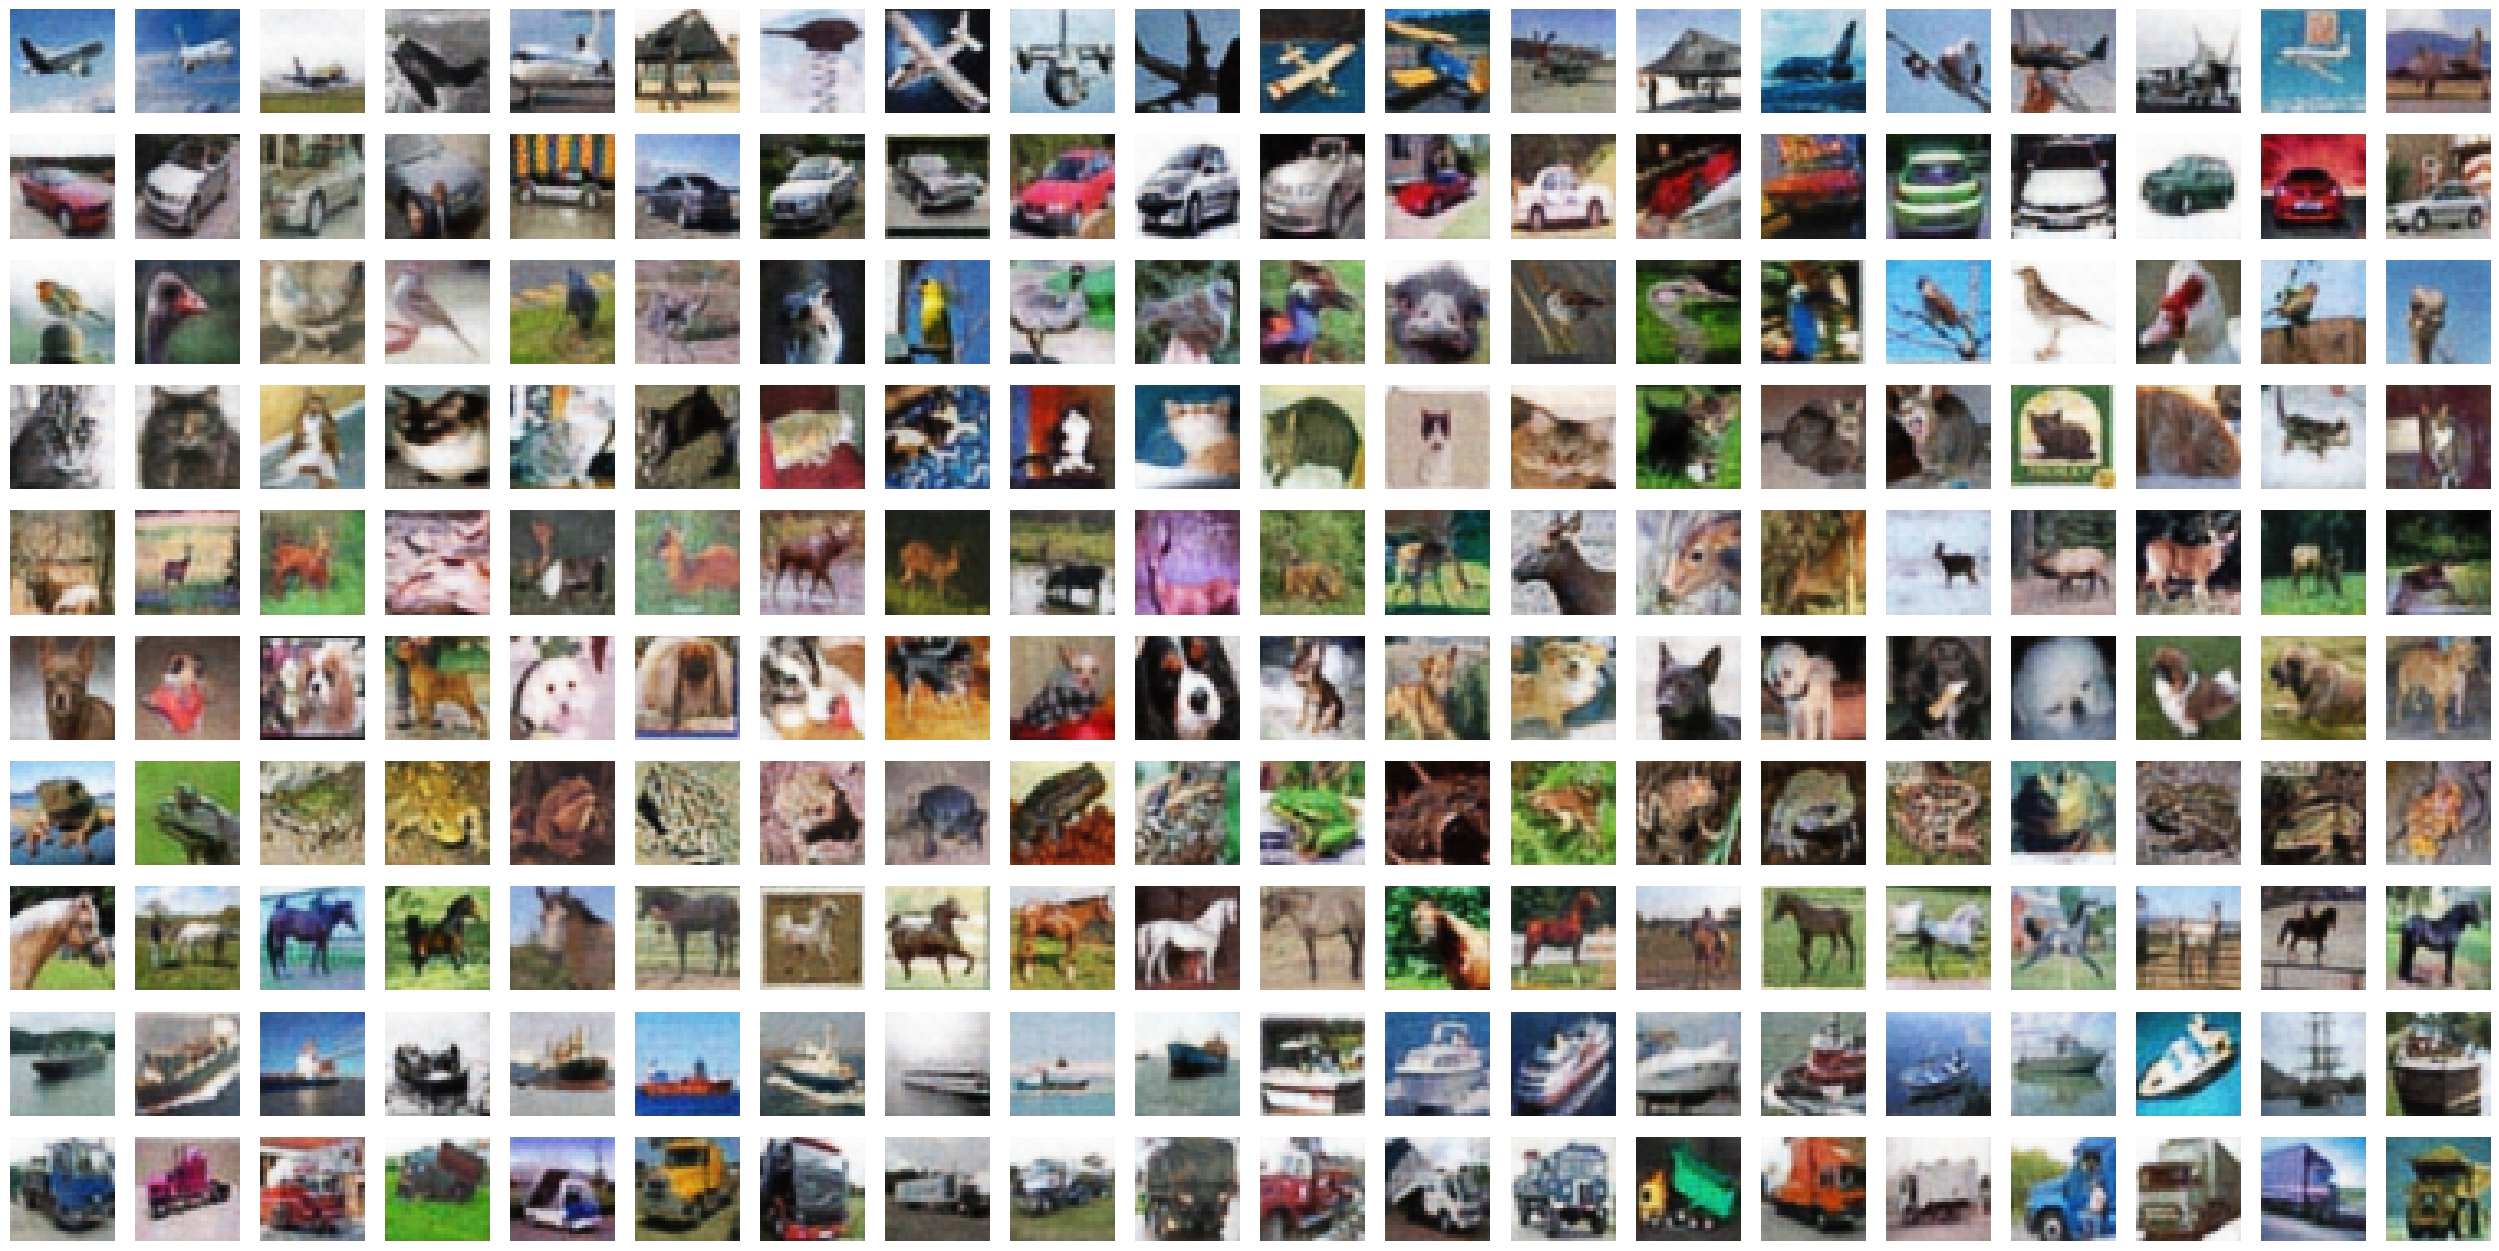

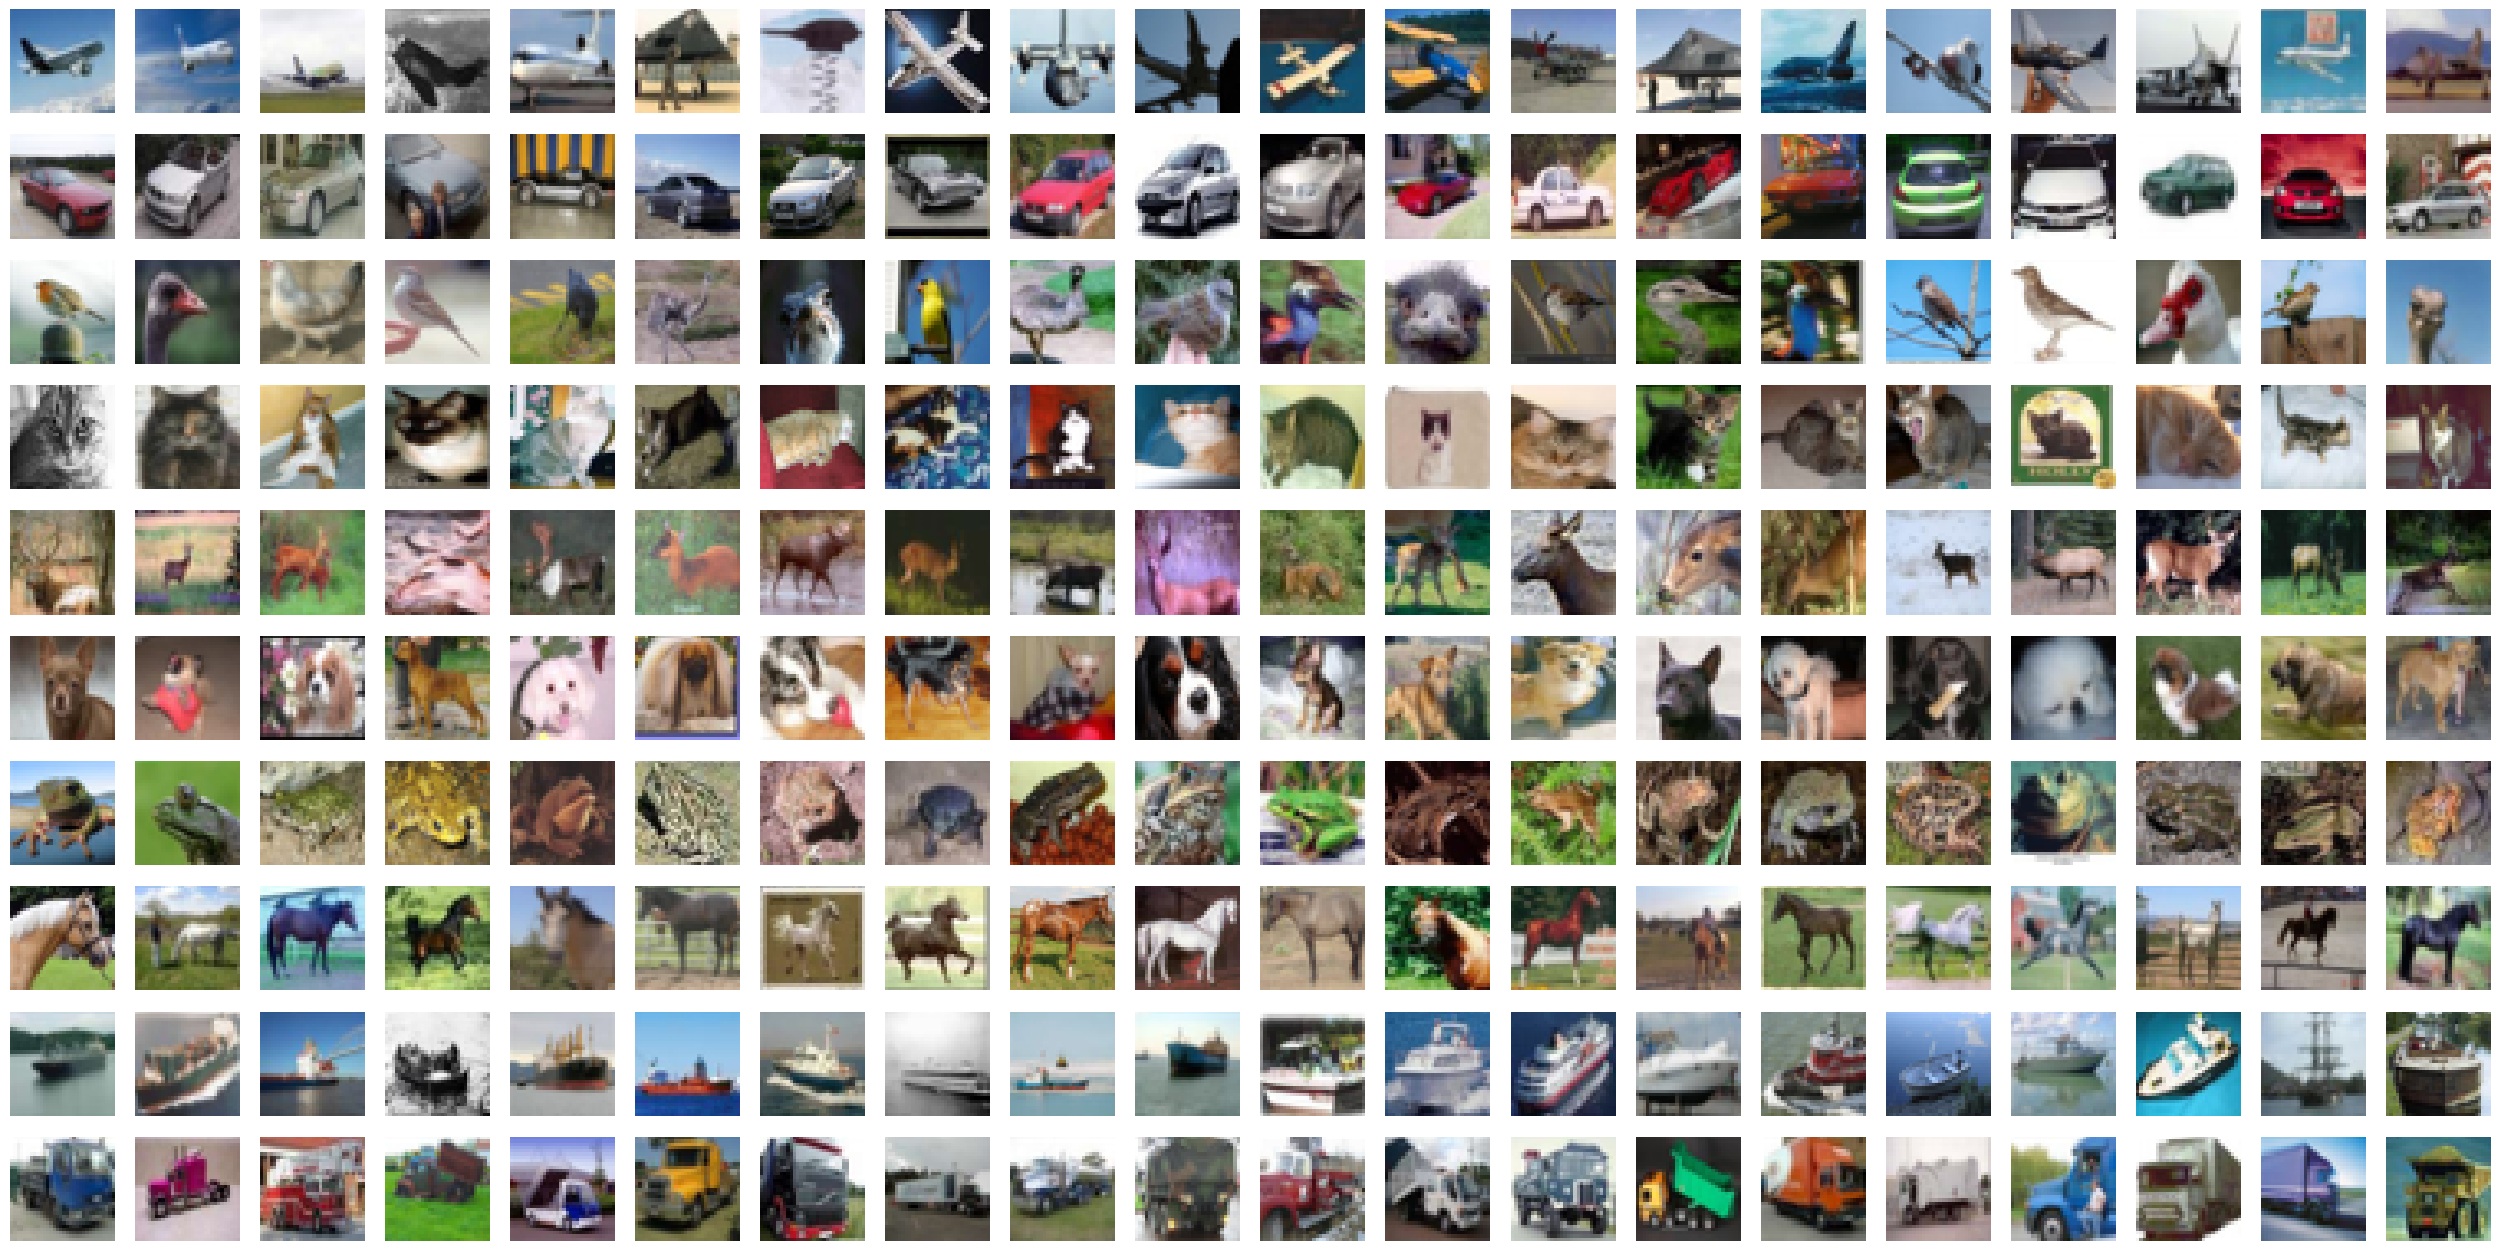

In [19]:
plt.figure(figsize=(32, 16))
for class_ in range(num_class):
    for i in range(plot_num):
        plt.subplot(num_class, plot_num, class_ * plot_num + i + 1)
        plt.imshow(sampled_X_AE_class[class_][i], cmap='gray', vmin=0, vmax=255)
        plt.axis('off')  # Hide axes

plt.show()

# Find the nearest distance between every new sample among the training set in terms of norm.
plt.figure(figsize=(32, 16))
for class_ in range(num_class):
    for i in range(plot_num):
        norm = [np.linalg.norm(sampled_X_AE_class[class_][i] - p) for p in AE_class[class_]]
        idx = np.argmin(norm)
        plt.subplot(num_class, plot_num, class_ * plot_num + i + 1)
        plt.imshow(AE_class[class_][idx], cmap='gray', vmin=0, vmax=255) # [0, 255]
        plt.axis('off')  # Hide axes

plt.show()

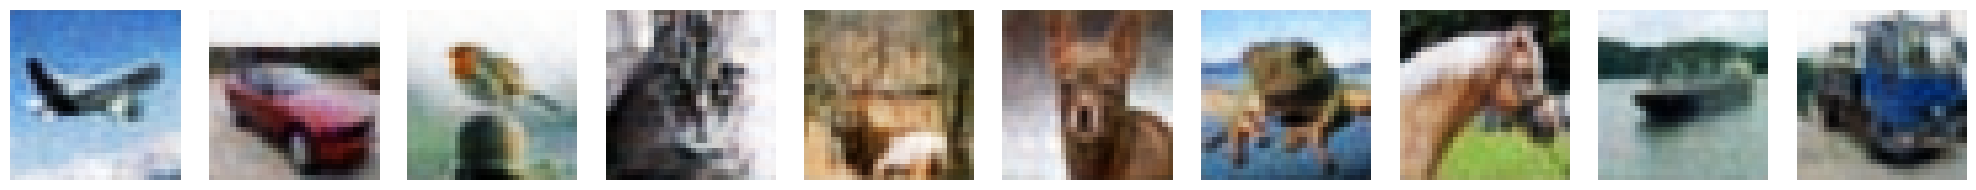

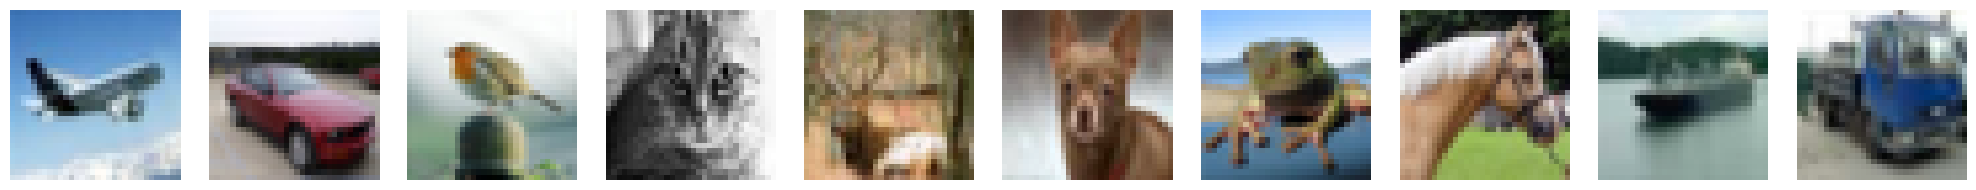

In [20]:
plt.figure(figsize=(20, 2))
for class_ in range(num_class):
    for i in range(paper_plot_num):
        plt.subplot(paper_plot_num, num_class, class_ * paper_plot_num + i + 1)
        plt.imshow(renormalize_image(sampled_X_AE_class[class_][i]).reshape(32, 32, 3), cmap='gray', vmin=0, vmax=255)
        plt.axis('off')  # Hide axes

plt.tight_layout()

plt.savefig('../Figures/CIFAR/else/AE.pdf', format='pdf')

plt.show()

# Find the nearest distance between every new sample among the training set in terms of norm.
plt.figure(figsize=(20, 2))
for class_ in range(num_class):
    for i in range(paper_plot_num):
        norm = [np.linalg.norm(sampled_X_AE_class[class_][i].reshape((32, 32, 3)) - p.reshape((32, 32, 3))) for p in AE_class[class_]]
        idx = np.argmin(norm)
        plt.subplot(paper_plot_num, num_class, class_ * paper_plot_num + i + 1)
        plt.imshow(renormalize_image(AE_class[class_][idx]).reshape((32, 32, 3)), cmap='gray', vmin=0, vmax=255) # [0, 255]
        plt.axis('off')  # Hide axes

plt.tight_layout()

plt.savefig('../Figures/CIFAR/else/AE_compare.pdf', format='pdf')

plt.show()

## Mixup

In [21]:
def mixup_data(x, y, alpha=1.0, device='cuda'):
    """
    Perform mixup on a batch of data.

    Args:
        x: Input features (batch_size, feature_dim)
        y: Labels (batch_size,)
        alpha: Beta distribution parameter for mixup
        device: Device to use

    Returns:
        mixed_x: Mixed inputs
        y_a: First set of labels
        y_b: Second set of labels
        lam: Mixing coefficient
    """
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1.0

    batch_size = x.size(0)

    # Generate random permutation of batch indices
    index = torch.randperm(batch_size).to(device)

    # Mix inputs: x_mixed = lam * x_i + (1 - lam) * x_j
    mixed_x = lam * x + (1 - lam) * x[index]

    # Return both labels for soft label computation
    y_a, y_b = y, y[index]

    return mixed_x, y_a, y_b, lam

def mixup_criterion(pred, y_a, y_b, lam, num_classes):
    """
    Compute mixup loss with soft labels.

    Soft label = lam * one_hot(y_a) + (1 - lam) * one_hot(y_b)
    Loss = CrossEntropy(pred, soft_label)

    Args:
        pred: Model predictions (logits) of shape (batch_size, num_classes)
        y_a: First set of labels (batch_size,)
        y_b: Second set of labels (batch_size,)
        lam: Mixing coefficient
        num_classes: Number of classes

    Returns:
        loss: Scalar loss value
    """
    criterion = nn.CrossEntropyLoss()
    # No one-hot conversion is needed
    loss = lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)
    return loss

def train_model_with_mixup(model, train_loader, criterion, optimizer, scheduler, num_epochs, alpha=1.0, num_classes=None, device='cuda'):
    """
    Train model with Mixup augmentation.

    Args:
        model: Neural network model
        train_loader: DataLoader for training data
        criterion: Loss function (not used for mixup, but kept for compatibility)
        optimizer: Optimizer
        scheduler: Learning rate scheduler
        num_epochs: Number of training epochs
        alpha: Mixup alpha parameter (0 means no mixup)
        num_classes: Number of classes (required for soft labels)
        device: Device to use
    """
    train_loss = []
    model.to(device)

    for epoch in tqdm(range(num_epochs)):
        model.train()
        train_epoch_loss = 0.0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            # Apply mixup
            if alpha > 0:
                mixed_images, labels_a, labels_b, lam = mixup_data(images, labels, alpha, device)

                optimizer.zero_grad()
                outputs = model(mixed_images)

                # Compute mixup loss with soft labels
                loss = mixup_criterion(outputs, labels_a, labels_b, lam, num_classes)
            else:
                # No mixup
                optimizer.zero_grad()
                outputs = model(images)
                loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()
            train_epoch_loss += loss.item()

        scheduler.step()
        train_loss.append(train_epoch_loss)

    plt.plot(train_loss)

## Classification Performance

### Dataset Preparation

### ResNet18 Model

In [22]:
# Helper function to create a DataLoader for augmented datasets
def prepare_augmented_dataset(original_dataset, augmented_data, augmented_labels, transform, batch_size, augmented_ratio=1.0):
    # Reduce the size of augmented data according to the augmented_ratio
    total_augmented = len(augmented_data)
    num_selected = int(total_augmented * augmented_ratio)

    if num_selected < total_augmented:  # Sample only if reducing
        indices = np.random.choice(total_augmented, num_selected, replace=False)
        augmented_data = augmented_data[indices]
        augmented_labels = augmented_labels[indices]

    # Create dataset from augmented data
    augmented_dataset = NumpyDataset(data=augmented_data, labels=augmented_labels, transform=transform)

    # Combine with the original CIFAR-10 dataset
    combined_dataset = ConcatDataset([original_dataset, augmented_dataset])

    # Create a DataLoader for the combined dataset
    return DataLoader(dataset=combined_dataset, batch_size=batch_size, shuffle=True)

# Main function to prepare datasets and loaders
def create_datasets_and_loaders(batch_size=64, augmented_ratio=1.0):
    # Transformations
    transform_standard = transforms.Compose([
        transforms.RandomRotation(degrees=15),
        transforms.RandomAffine(
            degrees=0,
            translate=(0.1, 0.1),
            scale=(0.9, 1.1),
            shear=10,
        ),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.4914, 0.4822, 0.4465], std=[0.2023, 0.1994, 0.2010]),
    ])
    transform_none = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.4914, 0.4822, 0.4465], std=[0.2023, 0.1994, 0.2010]),
    ])
    transform_none_augmented = transforms.Compose([
        transforms.Normalize(mean=[0.4914, 0.4822, 0.4465], std=[0.2023, 0.1994, 0.2010]),
    ])

    # CIFAR-10 Datasets
    cifar_train_standard = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_standard)
    cifar_train_none = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_none)

    augmented_data_PNL = []
    labels_PNL = []
    augmented_data_AE = []
    labels_AE = []

    for class_ in range(num_class):
        for img_PNL in sampled_X_BP_class[class_]:
            augmented_data_PNL.append(renormalize_image(img_PNL).reshape((32, 32, 3)))
            labels_PNL.append(class_)

        for img_AE in sampled_X_AE_class[class_]:
            augmented_data_AE.append(img_AE)
            labels_AE.append(class_)

    augmented_data_PNL = np.array(augmented_data_PNL)
    labels_PNL = np.array(labels_PNL)
    augmented_data_AE = np.array(augmented_data_AE)
    labels_AE = np.array(labels_AE)

    # Combine CIFAR-10 with a subset of augmented data based on augmented_ratio
    train_loader_PNL = prepare_augmented_dataset(cifar_train_none, augmented_data_PNL, labels_PNL,
                                                transform_none_augmented, batch_size, augmented_ratio)
    train_loader_AE = prepare_augmented_dataset(cifar_train_none, augmented_data_AE, labels_AE,
                                               transform_none_augmented, batch_size, augmented_ratio)

    # DataLoader for CIFAR-10 only
    train_loader_standard = DataLoader(cifar_train_standard, batch_size=batch_size, shuffle=True)
    train_loader_none = DataLoader(cifar_train_none, batch_size=batch_size, shuffle=True)

    return {
        "standard": train_loader_standard,
        "none": train_loader_none,
        "PNL_augmented": train_loader_PNL,
        "AE_augmented": train_loader_AE,
    }

# Create dictionaries of loaders for different datasets
train_loader_standard = {}
train_loader_none = {}
train_loader_PNL = {}
train_loader_AE = {}

# Example Usage: Testing different dataset sizes
for ratio in [1.0]:  # Testing different proportions of augmented data
    print(f"Testing with augmented_ratio = {ratio}")
    loaders = create_datasets_and_loaders(batch_size=64, augmented_ratio=ratio)

    for name, loader in loaders.items():
        print(f"{name} loader:")
        for images, labels in loader:
            print(f"Images shape: {images.shape}, Labels shape: {labels.shape}")
            break

    train_loader_standard[ratio] = loaders["standard"]
    train_loader_none[ratio] = loaders["none"]
    train_loader_PNL[ratio] = loaders["PNL_augmented"]
    train_loader_AE[ratio] = loaders["AE_augmented"]

Testing with augmented_ratio = 1.0
standard loader:
Images shape: torch.Size([64, 3, 32, 32]), Labels shape: torch.Size([64])
none loader:
Images shape: torch.Size([64, 3, 32, 32]), Labels shape: torch.Size([64])
PNL_augmented loader:
Images shape: torch.Size([64, 3, 32, 32]), Labels shape: torch.Size([64])
AE_augmented loader:
Images shape: torch.Size([64, 3, 32, 32]), Labels shape: torch.Size([64])


In [23]:
class ResNetModel(nn.Module):
    def __init__(self, num_classes=10):
        super(ResNetModel, self).__init__()
        self.resnet = models.resnet18(pretrained=False)  # Load ResNet18
        # Adjust first convolution for CIFAR-10
        self.resnet.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.resnet.maxpool = nn.Identity()  # Remove max-pooling layer
        self.resnet.fc = nn.Linear(self.resnet.fc.in_features, num_classes)  # Adjust for CIFAR-10 classes

    def forward(self, x):
        return self.resnet(x)

def train_model(model, train_loader, criterion, optimizer, scheduler, num_epochs, device='cuda'):
    train_loss = []
    model.to(device)
    for epoch in tqdm(range(num_epochs)):
        model.train()
        train_epoch_loss = 0.0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_epoch_loss += loss.item()

        scheduler.step()
        train_loss.append(train_epoch_loss)

    plt.plot(train_loss)

def test_model(model, test_loader, device='cuda'):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    return accuracy

def bootstrapping(train_loader, test_dataset, num_epochs=100, learning_rate=1e-1, n_bootstrap=20, device='cuda'):
    """
    Train the ResNet model on the training dataset, and evaluate it using bootstrapping on the test dataset.

    Args:
        train_loader: DataLoader for training data.
        test_dataset: Dataset object for the test data.
        num_epochs: Number of epochs for training.
        learning_rate: Learning rate for the optimizer.
        device: Device to run the training on ('cuda' or 'cpu').

    Returns:
        Prints the mean accuracy and 95% confidence interval after bootstrapping.
    """
    # Initialize the model, loss, optimizer, and scheduler
    model = ResNetModel(num_classes=10).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9, weight_decay=5e-4)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.1)  # Decay LR every 30 epochs

    # Train the model
    train_model(model, train_loader, criterion, optimizer, scheduler, num_epochs=num_epochs, device=device)

    # Perform bootstrapping
    accuracies = []

    num_test_samples = len(test_dataset) // 2
    for i in range(n_bootstrap):
        indices = torch.randint(len(test_dataset), size=(num_test_samples,))  # Sample 500 random indices
        bootstrap_subset = Subset(test_dataset, indices)
        bootstrap_loader = DataLoader(dataset=bootstrap_subset, batch_size=num_test_samples, shuffle=False)

        accuracy = test_model(model, bootstrap_loader, device=device)
        accuracies.append(accuracy)

    # Compute statistics
    mean_accuracy = np.mean(accuracies)
    std_accuracy = np.std(accuracies)

    print(f"Mean accuracy: {mean_accuracy:.2f}%")
    print(f"Standard deviation: {std_accuracy:.2f}")

### Manifold Mixup

In [24]:
class ResNetModel_ManifoldMixup(nn.Module):
    """
    ResNet18 adapted for CIFAR-10 with Manifold Mixup support.
    """
    def __init__(self, num_classes=10):
        super(ResNetModel_ManifoldMixup, self).__init__()
        self.resnet = models.resnet18(pretrained=False)
        # Adjust first convolution for CIFAR-10
        self.resnet.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.resnet.maxpool = nn.Identity()  # Remove max-pooling layer

        # Store intermediate layers for manifold mixup
        self.layer0 = nn.Sequential(self.resnet.conv1, self.resnet.bn1, self.resnet.relu)
        self.layer1 = self.resnet.layer1
        self.layer2 = self.resnet.layer2
        self.layer3 = self.resnet.layer3
        self.layer4 = self.resnet.layer4
        self.avgpool = self.resnet.avgpool
        self.fc = nn.Linear(self.resnet.fc.in_features, num_classes)

    def forward(self, x, mixup_layer=None, mixup_index=None, mixup_lam=None):
        """
        Forward pass with optional manifold mixup.

        Args:
            x: Input images
            mixup_layer: Layer at which to apply mixup (None, 0, 1, 2, 3, or 4)
            mixup_index: Indices for mixing samples
            mixup_lam: Mixing coefficient
        """
        # Layer 0: Initial conv + bn + relu
        if mixup_layer == 0 and mixup_index is not None and mixup_lam is not None:
            x = mixup_lam * x + (1 - mixup_lam) * x[mixup_index]

        x = self.layer0(x)

        # Layer 1
        if mixup_layer == 1 and mixup_index is not None and mixup_lam is not None:
            x = mixup_lam * x + (1 - mixup_lam) * x[mixup_index]
        x = self.layer1(x)

        # Layer 2
        if mixup_layer == 2 and mixup_index is not None and mixup_lam is not None:
            x = mixup_lam * x + (1 - mixup_lam) * x[mixup_index]
        x = self.layer2(x)

        # Layer 3
        if mixup_layer == 3 and mixup_index is not None and mixup_lam is not None:
            x = mixup_lam * x + (1 - mixup_lam) * x[mixup_index]
        x = self.layer3(x)

        # Layer 4
        if mixup_layer == 4 and mixup_index is not None and mixup_lam is not None:
            x = mixup_lam * x + (1 - mixup_lam) * x[mixup_index]
        x = self.layer4(x)

        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)

        return x

def train_model_with_manifold_mixup(model, train_loader, criterion, optimizer, scheduler, num_epochs, alpha=1.0, num_classes=None, device='cuda'):
    """
    Train ResNet model with Manifold Mixup augmentation.

    Args:
        model: ResNetModel_ManifoldMixup
        train_loader: DataLoader for training data
        criterion: Loss function (not used for mixup, but kept for compatibility)
        optimizer: Optimizer
        scheduler: Learning rate scheduler
        num_epochs: Number of training epochs
        alpha: Mixup alpha parameter (0 means no mixup)
        num_classes: Number of classes (required for soft labels)
        device: Device to use
    """
    train_loss = []
    model.to(device)

    # Number of possible mixup layers (0-4 for ResNet)
    num_layers = 5

    for epoch in tqdm(range(num_epochs)):
        model.train()
        train_epoch_loss = 0.0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            # Apply manifold mixup
            if alpha > 0:
                # Randomly select which layer to apply mixup
                mixup_layer = np.random.randint(0, num_layers)

                # Sample mixing coefficient
                lam = np.random.beta(alpha, alpha)

                # Generate random permutation
                batch_size = images.size(0)
                index = torch.randperm(batch_size).to(device)

                optimizer.zero_grad()

                # Forward pass with manifold mixup
                outputs = model(images, mixup_layer=mixup_layer, mixup_index=index, mixup_lam=lam)

                # Compute mixup loss with soft labels
                loss = mixup_criterion(outputs, labels, labels[index], lam, num_classes)
            else:
                # No mixup
                optimizer.zero_grad()
                outputs = model(images)
                loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()
            train_epoch_loss += loss.item()

        scheduler.step()
        train_loss.append(train_epoch_loss)

    plt.plot(train_loss)

def bootstrapping_mixup(train_loader, test_dataset, num_epochs=100, learning_rate=1e-1, alpha=1.0, n_bootstrap=20, device='cuda'):
    """
    Train ResNet with Mixup and evaluate using bootstrapping.

    Args:
        train_loader: DataLoader for training data
        test_dataset: Dataset object for the test data
        num_epochs: Number of epochs for training
        learning_rate: Learning rate for the optimizer
        alpha: Mixup alpha parameter
        n_bootstrap: Number of bootstrap iterations
        device: Device to run the training on ('cuda' or 'cpu')

    Returns:
        Prints the mean accuracy and standard deviation after bootstrapping
    """
    # Initialize the model, loss, optimizer, and scheduler
    model = ResNetModel(num_classes=num_class).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9, weight_decay=5e-4)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.1)

    # Train the model with Mixup
    train_model_with_mixup(model, train_loader, criterion, optimizer, scheduler,
                          num_epochs=num_epochs, alpha=alpha, num_classes=num_class, device=device)

    # Perform bootstrapping
    accuracies = []
    num_test_samples = len(test_dataset) // 2

    for i in range(n_bootstrap):
        indices = torch.randint(len(test_dataset), size=(num_test_samples,))
        bootstrap_subset = Subset(test_dataset, indices)
        bootstrap_loader = DataLoader(dataset=bootstrap_subset, batch_size=num_test_samples, shuffle=False)

        accuracy = test_model(model, bootstrap_loader, device=device)
        accuracies.append(accuracy)

    # Compute statistics
    mean_accuracy = np.mean(accuracies)
    std_accuracy = np.std(accuracies)

    print(f"Mean accuracy: {mean_accuracy:.2f}%")
    print(f"Standard deviation: {std_accuracy:.2f}")

def bootstrapping_manifold_mixup(train_loader, test_dataset, num_epochs=100, learning_rate=1e-1, alpha=1.0, n_bootstrap=20, device='cuda'):
    """
    Train ResNet with Manifold Mixup and evaluate using bootstrapping.

    Args:
        train_loader: DataLoader for training data
        test_dataset: Dataset object for the test data
        num_epochs: Number of epochs for training
        learning_rate: Learning rate for the optimizer
        alpha: Manifold Mixup alpha parameter
        n_bootstrap: Number of bootstrap iterations
        device: Device to run the training on ('cuda' or 'cpu')

    Returns:
        Prints the mean accuracy and standard deviation after bootstrapping
    """
    # Initialize the model, loss, optimizer, and scheduler
    model = ResNetModel_ManifoldMixup(num_classes=num_class).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9, weight_decay=5e-4)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.1)

    # Train the model with Manifold Mixup
    train_model_with_manifold_mixup(model, train_loader, criterion, optimizer, scheduler,
                                   num_epochs=num_epochs, alpha=alpha, num_classes=num_class, device=device)

    # Perform bootstrapping
    accuracies = []
    num_test_samples = len(test_dataset) // 2

    for i in range(n_bootstrap):
        indices = torch.randint(len(test_dataset), size=(num_test_samples,))
        bootstrap_subset = Subset(test_dataset, indices)
        bootstrap_loader = DataLoader(dataset=bootstrap_subset, batch_size=num_test_samples, shuffle=False)

        # Use model without mixup for evaluation
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for features, labels in bootstrap_loader:
                features, labels = features.to(device), labels.to(device)
                outputs = model(features)  # No mixup during evaluation
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        accuracy = 100 * correct / total
        accuracies.append(accuracy)

    # Compute statistics
    mean_accuracy = np.mean(accuracies)
    std_accuracy = np.std(accuracies)

    print(f"Mean accuracy: {mean_accuracy:.2f}%")
    print(f"Standard deviation: {std_accuracy:.2f}")

print("Evaluation functions for Mixup and Manifold Mixup defined successfully")

Evaluation functions for Mixup and Manifold Mixup defined successfully


### Dataset Performance

In [ ]:
for ratio in [1.0]:
    print(f"Testing with augmented_ratio = {ratio}")
    print("Standard:")
    bootstrapping(train_loader_standard[ratio], test_dataset, num_epochs=50, learning_rate=0.1, device=device)
    print("None:")
    bootstrapping(train_loader_none[ratio], test_dataset, num_epochs=50, learning_rate=0.1, device=device)
    print("PNL:")
    bootstrapping(train_loader_PNL[ratio], test_dataset, num_epochs=50, learning_rate=0.1, device=device)
    print("AE:")
    bootstrapping(train_loader_AE[ratio], test_dataset, num_epochs=50, learning_rate=0.1, device=device)
    print("Mixup:")
    bootstrapping_mixup(train_loader_none[ratio], test_dataset, num_epochs=50, learning_rate=0.1, alpha=1.0, device=device)
    print("Manifold Mixup:")
    bootstrapping_manifold_mixup(train_loader_none[ratio], test_dataset, num_epochs=50, learning_rate=0.1, alpha=1.0, device=device)

Testing with augmented_ratio = 1.0
Standard:


100%|██████████| 50/50 [22:51<00:00, 27.43s/it]


Mean accuracy: 89.72%
Standard deviation: 0.41
None:


100%|██████████| 50/50 [18:30<00:00, 22.21s/it]


Mean accuracy: 88.59%
Standard deviation: 0.50
PNL:


100%|██████████| 50/50 [20:28<00:00, 24.57s/it]


Mean accuracy: 88.48%
Standard deviation: 0.38
AE:


 40%|████      | 20/50 [08:15<12:24, 24.81s/it]